In [1]:
import pandas as pd

In [2]:
births = pd.read_csv("births.csv")

births.head()

,provmin,urban,child_birth,age_cat,age,etnicity,parity
0,68,strong,"first line child birth, at home",25-29 year,26,Dutch,2
1,12,moderate,"first line child birth, outpatient",25-29 year,29,Dutch,1
2,99,not,"first line child birth, outpatient",25-29 year,25,Mediterranean,2
3,68,moderate,during pregnacy referred to specialist,30-34 year,30,Dutch,3
4,68,strong,"originally at home, referred to specialist",30-34 year,33,Dutch,1


In [3]:
births["home"] = births["child_birth"].apply(lambda x: "at_home" if x == "first line child birth, at home" else "not_at_home")

births["pari"] = births["parity"].apply(lambda x: "primi" if x == 1 else "multi")

births["etni"] = births["etnicity"].apply(lambda x: "Dutch" if x == "Dutch" else "Not Dutch")

In [4]:
from sklearn.linear_model import LogisticRegression

regression_model = LogisticRegression()

X = births[["pari", "age_cat", "etni", "urban"]]
y = births["home"]

X = pd.get_dummies(X, drop_first=True)


regression_model.fit(X, y)

from sklearn.metrics import classification_report

y_pred = regression_model.predict(X)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

     at_home       0.59      0.55      0.57     20506
 not_at_home       0.70      0.73      0.71     29197

    accuracy                           0.66     49703
   macro avg       0.64      0.64      0.64     49703
weighted avg       0.65      0.66      0.65     49703



[Text(0.5777138157894737, 0.95, 'pari_primi <= 0.5\ngini = 0.485\nsamples = 49703\nvalue = [20506, 29197]\nclass = not_at_home'),
 Text(0.34769736842105264, 0.85, 'etni_Not Dutch <= 0.5\ngini = 0.499\nsamples = 26326\nvalue = [13697, 12629]\nclass = at_home'),
 Text(0.4627055921052632, 0.8999999999999999, 'True  '),
 Text(0.23453947368421052, 0.75, 'urban_not <= 0.5\ngini = 0.489\nsamples = 22055\nvalue = [12674, 9381]\nclass = at_home'),
 Text(0.18486842105263157, 0.65, 'urban_strong <= 0.5\ngini = 0.484\nsamples = 19167\nvalue = [11287.0, 7880.0]\nclass = at_home'),
 Text(0.13815789473684212, 0.55, 'urban_very strong <= 0.5\ngini = 0.489\nsamples = 13708\nvalue = [7875, 5833]\nclass = at_home'),
 Text(0.09736842105263158, 0.45, 'age_cat_< 25 year <= 0.5\ngini = 0.492\nsamples = 10512\nvalue = [5939, 4573]\nclass = at_home'),
 Text(0.06842105263157895, 0.35, 'age_cat_30-34 year <= 0.5\ngini = 0.49\nsamples = 9955\nvalue = [5669.0, 4286.0]\nclass = at_home'),
 Text(0.042105263157894736

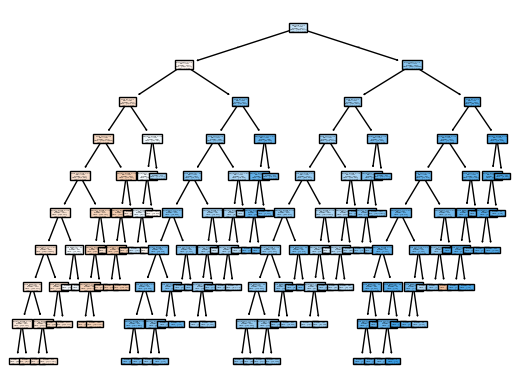

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree_model = DecisionTreeClassifier()

tree_model.fit(X, y)

plot_tree(tree_model, feature_names=X.columns, class_names=tree_model.classes_, filled=True)

In [ ]:
from sklearn.model_selection import cross_val_score

regression_scores = cross_val_score(regression_model, X, y, cv=5, scoring="accuracy")
tree_scores = cross_val_score(tree_model, X, y, cv=5, scoring="accuracy")

print("Logistic Regression Accuracy:", regression_scores.mean())
print("Decision Tree Accuracy:", tree_scores.mean())

Logistic Regression Accuracy: 0.6559765331755142
Decision Tree Accuracy: 0.6574251524639234
